In [1]:
# =============================================================================
# Notebook 03 — Modelo de Previsão de Volume do PS
# Sistema de Painéis Hospitalares — Central de ML (P30)
# =============================================================================
# Este notebook:
#   1. Constrói o dataset de treino com 32 features
#   2. Faz split temporal (treino / validação / teste)
#   3. Treina baseline ingênuo (régua de comparação)
#   4. Treina LightGBM
#   5. Avalia métricas (MAE, MAPE)
#   6. Analisa importância de features
#   7. Serializa o modelo final (.pkl)
# =============================================================================

import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib
import holidays

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

print(f"Python: {sys.version.split()[0]}")
print(f"LightGBM: {lgb.__version__}")
print("Setup OK")

Python: 3.11.9
LightGBM: 4.5.0
Setup OK


In [2]:
# =============================================================================
# Carrega a série diária enriquecida do Notebook 02
# =============================================================================

df = pd.read_parquet('../data/serie_diaria_enriquecida.parquet')
print(f"Linhas: {len(df)}")
print(f"Período: {df.index.min().date()} até {df.index.max().date()}")
print(f"Colunas disponíveis: {list(df.columns)}")

Linhas: 1000
Período: 2023-07-14 até 2026-04-08
Colunas disponíveis: ['chegadas', 'flag_surto_dengue_2024', 'is_feriado', 'is_vespera_feriado', 'is_pos_feriado', 'temp_max', 'temp_min', 'temp_media', 'precipitacao_mm', 'chuva_mm', 'horas_chuva', 'vento_max', 'umidade_media']


In [3]:
# =============================================================================
# Construção das 32 features planejadas no Notebook 02
# =============================================================================

# --- CALENDÁRIO ---
df['ano'] = df.index.year
df['mes'] = df.index.month
df['dia_mes'] = df.index.day
df['dia_semana'] = df.index.dayofweek          # 0=Seg, 6=Dom
df['dia_ano'] = df.index.dayofyear
df['semana_ano'] = df.index.isocalendar().week.astype(int).values
df['trimestre'] = df.index.quarter

# Flags binárias
df['is_segunda'] = (df['dia_semana'] == 0).astype(int)
df['is_fim_semana'] = (df['dia_semana'] >= 5).astype(int)

# Codificação cíclica (sen/cos) — permite ao modelo entender que
# domingo(6) é "vizinho" de segunda(0), e dezembro(12) é vizinho de janeiro(1)
df['dia_semana_sin'] = np.sin(2 * np.pi * df['dia_semana'] / 7)
df['dia_semana_cos'] = np.cos(2 * np.pi * df['dia_semana'] / 7)
df['mes_sin'] = np.sin(2 * np.pi * df['mes'] / 12)
df['mes_cos'] = np.cos(2 * np.pi * df['mes'] / 12)

# Quinzena do mês (dias 1-15 vs 16-31) — captura efeito de pagamento
df['is_primeira_quinzena'] = (df['dia_mes'] <= 15).astype(int)

# --- LAGS ---
df['lag_1d'] = df['chegadas'].shift(1)
df['lag_2d'] = df['chegadas'].shift(2)
df['lag_7d'] = df['chegadas'].shift(7)
df['lag_14d'] = df['chegadas'].shift(14)

# Médias móveis
df['media_movel_7d'] = df['chegadas'].shift(1).rolling(7).mean()
df['media_movel_28d'] = df['chegadas'].shift(1).rolling(28).mean()
df['std_movel_7d'] = df['chegadas'].shift(1).rolling(7).std()

# IMPORTANTE: os shifts garantem que só usamos dados do PASSADO
# shift(1) = dado de ontem, shift(7) = dado de 7 dias atrás
# Nunca usamos dado do próprio dia (seria data leakage)

# --- FERIADOS (já criados no notebook 02, mas vamos garantir) ---
if 'is_feriado' not in df.columns:
    anos = list(range(df.index.year.min(), df.index.year.max() + 1))
    feriados_br = holidays.Brazil(years=anos, subdiv='DF')
    feriado_datas = set(feriados_br.keys())
    df['is_feriado'] = df.index.to_series().apply(lambda d: d.date() in feriados_br).astype(int)
    df['is_vespera_feriado'] = df.index.to_series().apply(lambda d: (d.date() + timedelta(days=1)) in feriado_datas).astype(int)
    df['is_pos_feriado'] = df.index.to_series().apply(lambda d: (d.date() - timedelta(days=1)) in feriado_datas).astype(int)

# --- Contagem de features ---
print(f"Total de colunas após feature engineering: {len(df.columns)}")
print(f"\nPrimeiras linhas do dataset completo:")
df.tail(3)

Total de colunas após feature engineering: 34

Primeiras linhas do dataset completo:


,chegadas,flag_surto_dengue_2024,is_feriado,is_vespera_feriado,is_pos_feriado,temp_max,temp_min,temp_media,precipitacao_mm,chuva_mm,...,mes_sin,mes_cos,is_primeira_quinzena,lag_1d,lag_2d,lag_7d,lag_14d,media_movel_7d,media_movel_28d,std_movel_7d
data,,,,,,,,,,,,,,,,,,,,,
2026-04-06,340,0,0,0,0,25.6,17.4,21.2,0.9,0.9,...,0.866025,-0.5,1,186.0,154.0,307.0,318.0,217.285714,224.071429,55.089970
2026-04-07,277,0,0,0,0,25.6,17.5,20.6,11.5,11.5,...,0.866025,-0.5,1,340.0,186.0,256.0,258.0,222.000000,225.571429,64.632293
2026-04-08,297,0,0,0,0,25.2,16.7,20.4,10.3,10.3,...,0.866025,-0.5,1,277.0,340.0,242.0,250.0,225.000000,226.964286,66.920351


In [4]:
# =============================================================================
# Remove as primeiras 28 linhas (NaN gerado pelos lags e médias móveis)
# Define X (features) e y (target)
# =============================================================================

# Lista de features que vão pro modelo
FEATURES = [
    # Calendário
    'ano', 'mes', 'dia_mes', 'dia_semana', 'dia_ano', 'semana_ano', 'trimestre',
    'is_segunda', 'is_fim_semana', 'is_primeira_quinzena',
    'dia_semana_sin', 'dia_semana_cos', 'mes_sin', 'mes_cos',
    # Feriados
    'is_feriado', 'is_vespera_feriado', 'is_pos_feriado',
    # Evento especial
    'flag_surto_dengue_2024',
    # Clima
    'temp_max', 'temp_min', 'temp_media',
    'precipitacao_mm', 'chuva_mm', 'horas_chuva',
    'umidade_media', 'vento_max',
    # Lags
    'lag_1d', 'lag_2d', 'lag_7d', 'lag_14d',
    'media_movel_7d', 'media_movel_28d', 'std_movel_7d',
]

TARGET = 'chegadas'

# Remove linhas com NaN (primeiros 28 dias por causa do rolling 28)
df_model = df.dropna(subset=FEATURES).copy()

print(f"Linhas originais: {len(df)}")
print(f"Linhas removidas (NaN dos lags): {len(df) - len(df_model)}")
print(f"Linhas para modelagem: {len(df_model)}")
print(f"Features: {len(FEATURES)}")
print(f"Target: {TARGET}")
print(f"\nPeríodo: {df_model.index.min().date()} até {df_model.index.max().date()}")

Linhas originais: 1000
Linhas removidas (NaN dos lags): 28
Linhas para modelagem: 972
Features: 33
Target: chegadas

Período: 2023-08-11 até 2026-04-08


In [5]:
# =============================================================================
# Split TEMPORAL — nunca aleatório em séries temporais
#
# Estratégia:
#   - Treino:    tudo até 31/12/2025 (~28 meses)
#   - Validação: jan/2026 — fev/2026 (2 meses — pra tunar hiperparâmetros)
#   - Teste:     mar/2026 — abr/2026 (últimos ~40 dias — resultado final)
#
# O teste NUNCA é visto durante treino ou tuning. É a "prova final".
# =============================================================================

CORTE_TREINO = '2025-12-31'
CORTE_VALIDACAO = '2026-02-28'

df_treino = df_model[df_model.index <= CORTE_TREINO]
df_valid  = df_model[(df_model.index > CORTE_TREINO) & (df_model.index <= CORTE_VALIDACAO)]
df_teste  = df_model[df_model.index > CORTE_VALIDACAO]

X_treino = df_treino[FEATURES]
y_treino = df_treino[TARGET]

X_valid = df_valid[FEATURES]
y_valid = df_valid[TARGET]

X_teste = df_teste[FEATURES]
y_teste = df_teste[TARGET]

print("SPLIT TEMPORAL")
print("=" * 60)
print(f"Treino:     {len(df_treino):4d} dias | {df_treino.index.min().date()} → {df_treino.index.max().date()}")
print(f"Validação:  {len(df_valid):4d} dias | {df_valid.index.min().date()} → {df_valid.index.max().date()}")
print(f"Teste:      {len(df_teste):4d} dias | {df_teste.index.min().date()} → {df_teste.index.max().date()}")
print(f"\nProporção: {len(df_treino)/len(df_model)*100:.0f}% / {len(df_valid)/len(df_model)*100:.0f}% / {len(df_teste)/len(df_model)*100:.0f}%")

SPLIT TEMPORAL
Treino:      874 dias | 2023-08-11 → 2025-12-31
Validação:    59 dias | 2026-01-01 → 2026-02-28
Teste:        39 dias | 2026-03-01 → 2026-04-08

Proporção: 90% / 6% / 4%


In [6]:
# =============================================================================
# Baseline: "a previsão é o que aconteceu no mesmo dia da semana passada"
# Esse é o modelo mais simples possível que captura sazonalidade semanal.
# Qualquer modelo de ML que não bata isso é inútil.
# =============================================================================

# Baseline na validação
pred_baseline_valid = df_valid['lag_7d'].values
mae_baseline_valid = mean_absolute_error(y_valid, pred_baseline_valid)
mape_baseline_valid = np.mean(np.abs((y_valid - pred_baseline_valid) / y_valid)) * 100

# Baseline no teste
pred_baseline_teste = df_teste['lag_7d'].values
mae_baseline_teste = mean_absolute_error(y_teste, pred_baseline_teste)
mape_baseline_teste = np.mean(np.abs((y_teste - pred_baseline_teste) / y_teste)) * 100

print("BASELINE (lag 7 dias — mesmo dia da semana passada)")
print("=" * 60)
print(f"Validação:  MAE = {mae_baseline_valid:.1f} chegadas | MAPE = {mape_baseline_valid:.1f}%")
print(f"Teste:      MAE = {mae_baseline_teste:.1f} chegadas | MAPE = {mape_baseline_teste:.1f}%")
print(f"\nInterpretação: usando só 'mesma coisa de semana passada',")
print(f"o erro médio é de ~{mae_baseline_teste:.0f} pacientes por dia.")
print(f"O modelo de ML precisa fazer MELHOR que isso pra justificar existir.")

BASELINE (lag 7 dias — mesmo dia da semana passada)
Validação:  MAE = 23.4 chegadas | MAPE = 13.0%
Teste:      MAE = 15.8 chegadas | MAPE = 7.0%

Interpretação: usando só 'mesma coisa de semana passada',
o erro médio é de ~16 pacientes por dia.
O modelo de ML precisa fazer MELHOR que isso pra justificar existir.


In [7]:
# =============================================================================
# LightGBM — Gradient Boosted Decision Trees
#
# Por que LightGBM e não XGBoost/Random Forest/Neural Network?
# 1. LightGBM é o estado da arte pra dados tabulares
# 2. Treina em segundos mesmo com 100k+ linhas
# 3. Lida nativamente com valores nulos
# 4. Feature importance nativa (interpretabilidade)
# 5. Funciona em CPU — não precisa de GPU
# 6. Usado em produção em hospitais do mundo todo
# =============================================================================

# Hiperparâmetros (conservadores pra começar — tuning vem depois)
params = {
    'objective': 'regression',
    'metric': 'mae',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,        # usa 80% das features por árvore (regularização)
    'bagging_fraction': 0.8,         # usa 80% dos dados por árvore (regularização)
    'bagging_freq': 5,
    'min_child_samples': 10,
    'verbose': -1,
    'seed': 42,
    'n_jobs': -1,
}

# Cria datasets do LightGBM
train_data = lgb.Dataset(X_treino, label=y_treino)
valid_data = lgb.Dataset(X_valid, label=y_valid, reference=train_data)

# Treina com early stopping (para quando validação para de melhorar)
print("Treinando LightGBM...")
model = lgb.train(
    params,
    train_data,
    num_boost_round=2000,
    valid_sets=[train_data, valid_data],
    valid_names=['treino', 'validacao'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100),
    ],
)

print(f"\n[OK] Modelo treinado!")
print(f"Árvores usadas: {model.best_iteration}")
print(f"MAE na validação: {model.best_score['validacao']['l1']:.2f}")

Treinando LightGBM...
Training until validation scores don't improve for 50 rounds
[100]	treino's l1: 8.07348	validacao's l1: 20.6666
Early stopping, best iteration is:
[85]	treino's l1: 9.13535	validacao's l1: 20.5572

[OK] Modelo treinado!
Árvores usadas: 85
MAE na validação: 20.56


In [8]:
# =============================================================================
# Métricas de avaliação — validação e teste
# =============================================================================

# Predições
pred_valid = model.predict(X_valid, num_iteration=model.best_iteration)
pred_teste = model.predict(X_teste, num_iteration=model.best_iteration)

# Métricas na validação
mae_valid = mean_absolute_error(y_valid, pred_valid)
rmse_valid = np.sqrt(mean_squared_error(y_valid, pred_valid))
mape_valid = np.mean(np.abs((y_valid - pred_valid) / y_valid)) * 100

# Métricas no teste
mae_teste = mean_absolute_error(y_teste, pred_teste)
rmse_teste = np.sqrt(mean_squared_error(y_teste, pred_teste))
mape_teste = np.mean(np.abs((y_teste - pred_teste) / y_teste)) * 100

# Melhoria sobre baseline
melhoria_valid = (1 - mae_valid / mae_baseline_valid) * 100
melhoria_teste = (1 - mae_teste / mae_baseline_teste) * 100

print("=" * 70)
print("RESULTADOS DO MODELO")
print("=" * 70)
print(f"\n{'Métrica':<25} {'Baseline':<15} {'LightGBM':<15} {'Melhoria'}")
print(f"{'-'*70}")
print(f"{'MAE Validação':<25} {mae_baseline_valid:<15.1f} {mae_valid:<15.1f} {melhoria_valid:+.1f}%")
print(f"{'MAE Teste':<25} {mae_baseline_teste:<15.1f} {mae_teste:<15.1f} {melhoria_teste:+.1f}%")
print(f"{'MAPE Validação':<25} {mape_baseline_valid:<15.1f}% {mape_valid:<15.1f}%")
print(f"{'MAPE Teste':<25} {mape_baseline_teste:<15.1f}% {mape_teste:<15.1f}%")
print(f"{'RMSE Teste':<25} {'—':<15} {rmse_teste:<15.1f}")
print(f"\n{'='*70}")
print(f"O modelo erra em média {mae_teste:.0f} pacientes por dia no período de teste.")
print(f"Para uma média de ~{y_teste.mean():.0f} chegadas/dia, isso é {mape_teste:.1f}% de erro.")
print(f"{'='*70}")

RESULTADOS DO MODELO

Métrica                   Baseline        LightGBM        Melhoria
----------------------------------------------------------------------
MAE Validação             23.4            20.6            +12.0%
MAE Teste                 15.8            14.1            +10.9%
MAPE Validação            13.0           % 12.3           %
MAPE Teste                7.0            % 6.3            %
RMSE Teste                —               16.0           

O modelo erra em média 14 pacientes por dia no período de teste.
Para uma média de ~229 chegadas/dia, isso é 6.3% de erro.


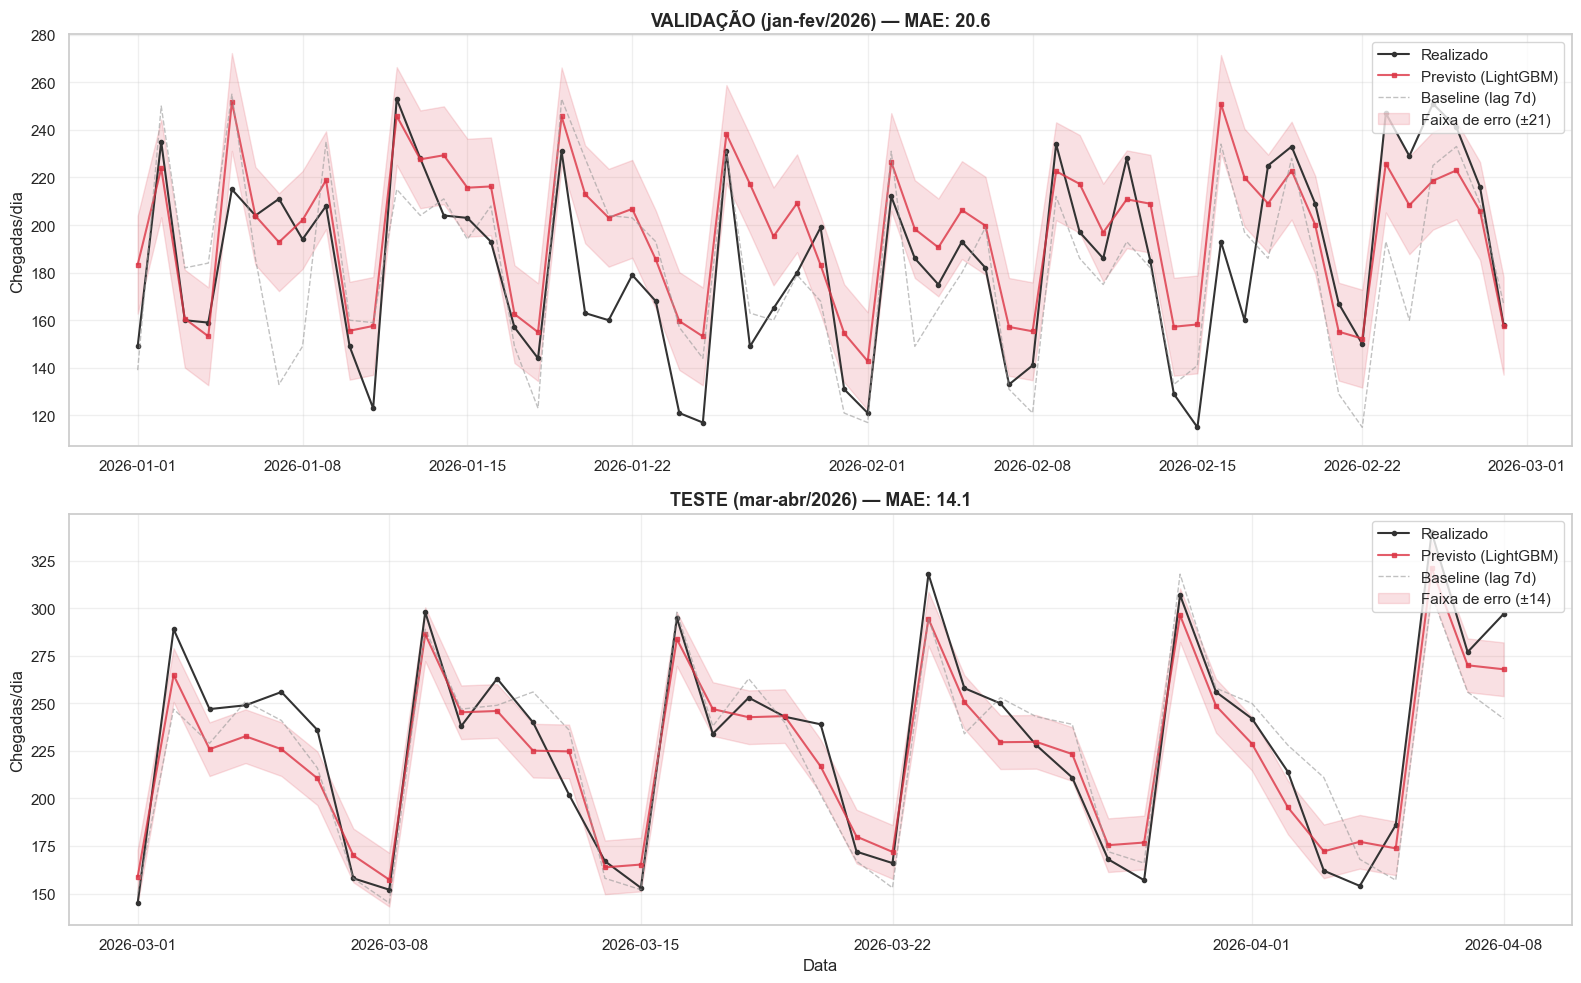

Se a linha vermelha acompanha a preta de perto, o modelo está bom.
Se a vermelha é claramente melhor que a cinza tracejada, o ML justifica existir.


In [9]:
# =============================================================================
# Visualização: previsto vs realizado nos últimos meses
# =============================================================================

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# --- Validação ---
axes[0].plot(df_valid.index, y_valid, color='#333', linewidth=1.5, label='Realizado', marker='o', markersize=3)
axes[0].plot(df_valid.index, pred_valid, color='#dc3545', linewidth=1.5, label='Previsto (LightGBM)', marker='s', markersize=3, alpha=0.8)
axes[0].plot(df_valid.index, pred_baseline_valid, color='#999', linewidth=1, linestyle='--', label='Baseline (lag 7d)', alpha=0.6)
axes[0].fill_between(df_valid.index, pred_valid - mae_valid, pred_valid + mae_valid, alpha=0.15, color='#dc3545', label=f'Faixa de erro (±{mae_valid:.0f})')
axes[0].set_title(f'VALIDAÇÃO (jan-fev/2026) — MAE: {mae_valid:.1f}', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Chegadas/dia')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# --- Teste ---
axes[1].plot(df_teste.index, y_teste, color='#333', linewidth=1.5, label='Realizado', marker='o', markersize=3)
axes[1].plot(df_teste.index, pred_teste, color='#dc3545', linewidth=1.5, label='Previsto (LightGBM)', marker='s', markersize=3, alpha=0.8)
axes[1].plot(df_teste.index, pred_baseline_teste, color='#999', linewidth=1, linestyle='--', label='Baseline (lag 7d)', alpha=0.6)
axes[1].fill_between(df_teste.index, pred_teste - mae_teste, pred_teste + mae_teste, alpha=0.15, color='#dc3545', label=f'Faixa de erro (±{mae_teste:.0f})')
axes[1].set_title(f'TESTE (mar-abr/2026) — MAE: {mae_teste:.1f}', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Chegadas/dia')
axes[1].set_xlabel('Data')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Se a linha vermelha acompanha a preta de perto, o modelo está bom.")
print("Se a vermelha é claramente melhor que a cinza tracejada, o ML justifica existir.")

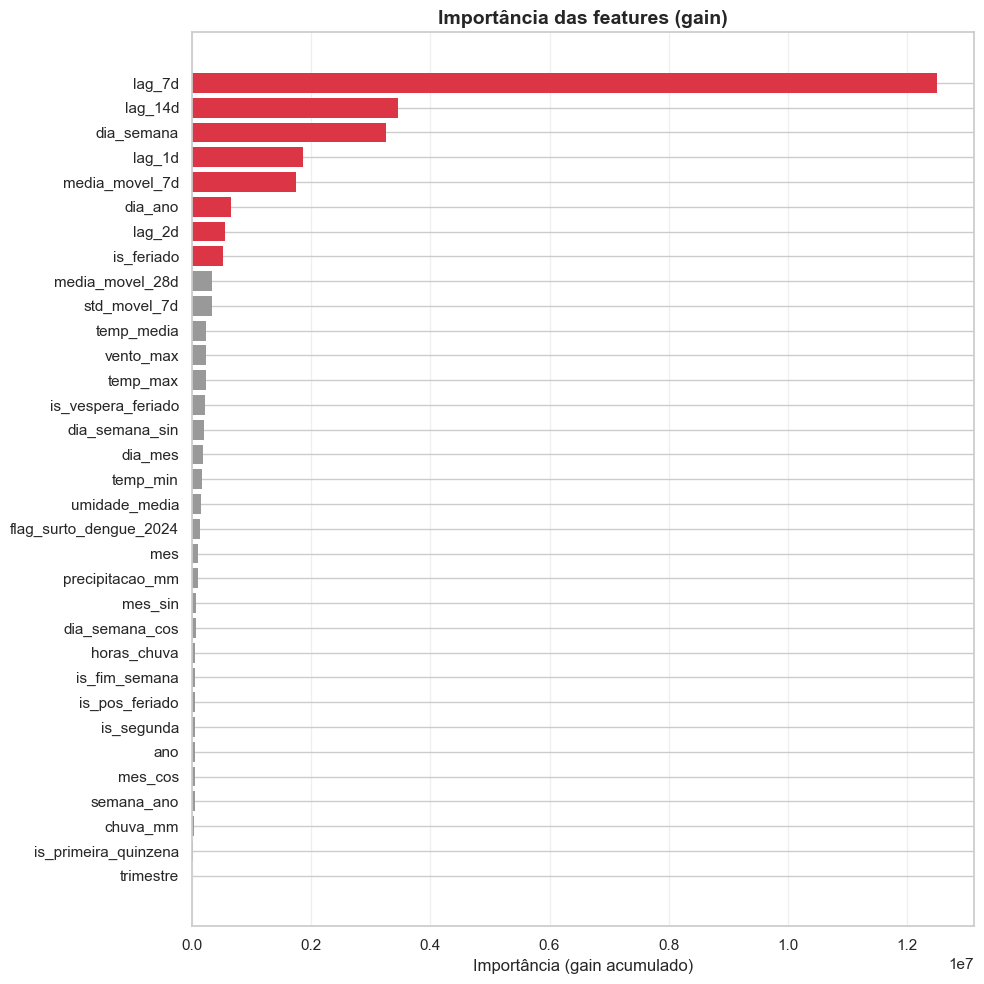


TOP 10 FEATURES:
  lag_7d                     45.3%
  lag_14d                    12.5%
  dia_semana                 11.8%
  lag_1d                      6.7%
  media_movel_7d              6.3%
  dia_ano                     2.4%
  lag_2d                      2.0%
  is_feriado                  1.9%
  media_movel_28d             1.2%
  std_movel_7d                1.2%


In [10]:
# =============================================================================
# Quais features o modelo mais usa? (interpretabilidade)
# =============================================================================

importance = pd.DataFrame({
    'feature': FEATURES,
    'importance': model.feature_importance(importance_type='gain'),
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['#dc3545' if imp > importance['importance'].quantile(0.75) else '#999'
          for imp in importance['importance']]
ax.barh(importance['feature'], importance['importance'], color=colors, edgecolor='none')
ax.set_title('Importância das features (gain)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importância (gain acumulado)')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# Top 10 com porcentagem
total_gain = importance['importance'].sum()
top10 = importance.tail(10).iloc[::-1]
print("\nTOP 10 FEATURES:")
print("=" * 50)
for _, row in top10.iterrows():
    pct = row['importance'] / total_gain * 100
    print(f"  {row['feature']:<25s} {pct:5.1f}%")

In [11]:
# =============================================================================
# Análise de erros: em quais situações o modelo erra mais?
# =============================================================================

df_erros = df_teste.copy()
df_erros['pred'] = pred_teste
df_erros['erro'] = df_erros['chegadas'] - df_erros['pred']
df_erros['erro_abs'] = np.abs(df_erros['erro'])
df_erros['dia_semana_nome'] = df_erros.index.day_name()

# Erro por dia da semana
print("ERRO MÉDIO ABSOLUTO POR DIA DA SEMANA")
print("=" * 50)
erro_por_dia = df_erros.groupby('dia_semana')['erro_abs'].mean()
dias_nomes = {0: 'Seg', 1: 'Ter', 2: 'Qua', 3: 'Qui', 4: 'Sex', 5: 'Sáb', 6: 'Dom'}
for dia, mae_dia in erro_por_dia.items():
    print(f"  {dias_nomes[dia]:<10s} MAE: {mae_dia:.1f}")

# Erro por tipo de dia
print(f"\n{'ERRO POR TIPO DE DIA':}")
print("=" * 50)
df_erros['tipo_dia'] = 'Dia útil'
df_erros.loc[df_erros['is_fim_semana'] == 1, 'tipo_dia'] = 'Fim de semana'
df_erros.loc[df_erros['is_feriado'] == 1, 'tipo_dia'] = 'Feriado'
print(df_erros.groupby('tipo_dia')['erro_abs'].agg(['mean', 'max', 'count']).round(1))

# Top 5 piores previsões
print(f"\n{'TOP 5 PIORES PREVISÕES (maior erro absoluto)':}")
print("=" * 60)
worst = df_erros.nlargest(5, 'erro_abs')[['chegadas', 'pred', 'erro', 'dia_semana_nome']]
print(worst.to_string())

ERRO MÉDIO ABSOLUTO POR DIA DA SEMANA
  Seg        MAE: 16.6
  Ter        MAE: 10.5
  Qua        MAE: 17.7
  Qui        MAE: 13.1
  Sex        MAE: 18.6
  Sáb        MAE: 10.8
  Dom        MAE: 11.5

ERRO POR TIPO DE DIA
               mean   max  count
tipo_dia                        
Dia útil       15.5  30.1     27
Feriado        10.2  10.2      1
Fim de semana  11.2  23.2     11

TOP 5 PIORES PREVISÕES (maior erro absoluto)
            chegadas        pred       erro dia_semana_nome
data                                                       
2026-03-05       256  225.913293  30.086707        Thursday
2026-04-08       297  267.939606  29.060394       Wednesday
2026-03-06       236  210.600539  25.399461          Friday
2026-03-02       289  264.910872  24.089128          Monday
2026-03-23       318  294.491653  23.508347          Monday


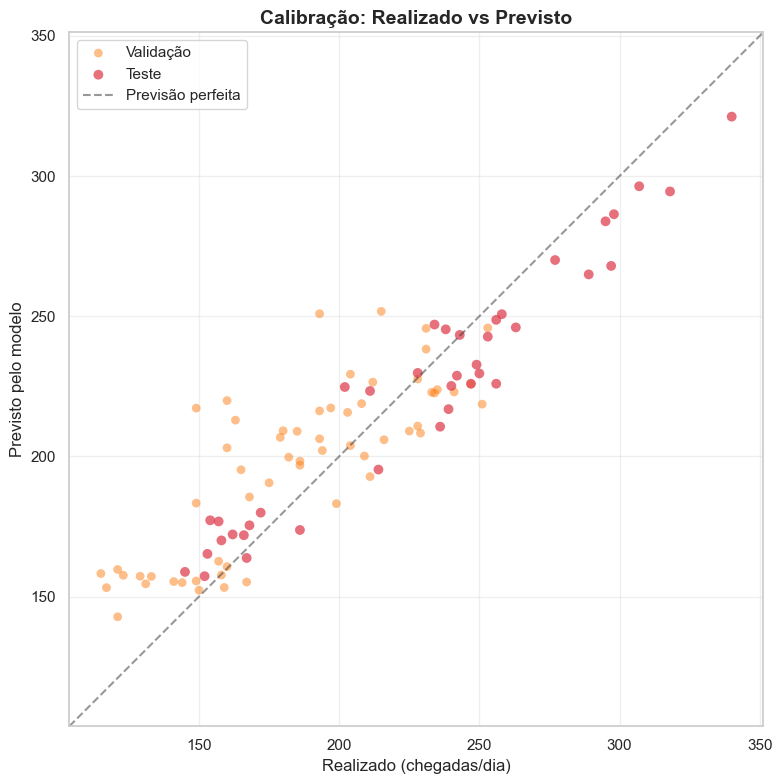

In [12]:
# =============================================================================
# Scatter: realizado vs previsto — o gráfico de "calibração"
# Pontos próximos da diagonal = modelo calibrado
# =============================================================================

fig, ax = plt.subplots(figsize=(8, 8))

# Validação
ax.scatter(y_valid, pred_valid, alpha=0.5, color='#fd7e14', label='Validação', s=40, edgecolors='none')
# Teste
ax.scatter(y_teste, pred_teste, alpha=0.7, color='#dc3545', label='Teste', s=50, edgecolors='none')

# Linha perfeita (diagonal)
lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, '--', color='#333', alpha=0.5, label='Previsão perfeita')
ax.set_xlim(lims)
ax.set_ylim(lims)

ax.set_title('Calibração: Realizado vs Previsto', fontsize=14, fontweight='bold')
ax.set_xlabel('Realizado (chegadas/dia)')
ax.set_ylabel('Previsto pelo modelo')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

In [13]:
# =============================================================================
# Salva o modelo treinado, metadados e lista de features
# Este .pkl é o que vai pro servidor de produção
# =============================================================================

MODEL_DIR = '../models'
os.makedirs(MODEL_DIR, exist_ok=True)

# Salva o modelo LightGBM
model_path = os.path.join(MODEL_DIR, 'ps_volume_v1.pkl')
joblib.dump(model, model_path)

# Salva metadados
meta = {
    'nome': 'ps_volume_v1',
    'descricao': 'Previsão de volume diário de chegadas no PS do HAC',
    'data_treino': datetime.now().strftime('%Y-%m-%d %H:%M'),
    'periodo_treino': f"{df_treino.index.min().date()} a {df_treino.index.max().date()}",
    'periodo_validacao': f"{df_valid.index.min().date()} a {df_valid.index.max().date()}",
    'periodo_teste': f"{df_teste.index.min().date()} a {df_teste.index.max().date()}",
    'num_features': len(FEATURES),
    'features': FEATURES,
    'target': TARGET,
    'metricas': {
        'mae_validacao': round(mae_valid, 2),
        'mae_teste': round(mae_teste, 2),
        'mape_teste': round(mape_teste, 2),
        'rmse_teste': round(rmse_teste, 2),
        'mae_baseline_teste': round(mae_baseline_teste, 2),
        'melhoria_sobre_baseline': f"{melhoria_teste:+.1f}%",
    },
    'hiperparametros': params,
    'num_arvores': model.best_iteration,
    'modelo': 'LightGBM (gradient boosted decision trees)',
    'versao': 'v1.0',
}

import json
meta_path = os.path.join(MODEL_DIR, 'ps_volume_v1_meta.json')
with open(meta_path, 'w', encoding='utf-8') as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print(f"[OK] Modelo salvo em:     {model_path}")
print(f"     Tamanho:              {os.path.getsize(model_path) / 1024:.1f} KB")
print(f"[OK] Metadados salvos em: {meta_path}")

print(f"\n{'=' * 70}")
print(f"MODELO PS_VOLUME_V1 — SERIALIZADO E PRONTO PRA PRODUÇÃO")
print(f"{'=' * 70}")
print(f"  MAE Teste:          {mae_teste:.1f} chegadas/dia")
print(f"  MAPE Teste:         {mape_teste:.1f}%")
print(f"  Melhoria vs baseline: {melhoria_teste:+.1f}%")
print(f"  Árvores:            {model.best_iteration}")
print(f"  Features:           {len(FEATURES)}")
print(f"{'=' * 70}")

[OK] Modelo salvo em:     ../models\ps_volume_v1.pkl
     Tamanho:              250.6 KB
[OK] Metadados salvos em: ../models\ps_volume_v1_meta.json

MODELO PS_VOLUME_V1 — SERIALIZADO E PRONTO PRA PRODUÇÃO
  MAE Teste:          14.1 chegadas/dia
  MAPE Teste:         6.3%
  Melhoria vs baseline: +10.9%
  Árvores:            85
  Features:           33


In [14]:
# =============================================================================
# Resumo e próximos passos
# =============================================================================

print("""
╔══════════════════════════════════════════════════════════════════════╗
║                    NOTEBOOK 03 — CONCLUÍDO                         ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                     ║
║  Modelo treinado, avaliado e serializado com sucesso.               ║
║                                                                     ║
║  Artefatos gerados:                                                 ║
║    models/ps_volume_v1.pkl       → modelo LightGBM                  ║
║    models/ps_volume_v1_meta.json → metadados e métricas             ║
║                                                                     ║
║  Próximos passos:                                                   ║
║    1. Worker (ml_ps_volume_worker.py)                               ║
║       - Roda diariamente, computa features, gera previsões 7 dias   ║
║       - Grava em tabela ml_ps_predicoes no PostgreSQL               ║
║       - Gerenciado via NSSM / Task Scheduler                        ║
║                                                                     ║
║    2. Backend Flask (painel30_routes.py)                             ║
║       - Endpoint /api/painel30/previsao-ps                          ║
║       - Endpoint /api/painel30/modelos (registry)                   ║
║       - Endpoint /api/painel30/metricas                             ║
║                                                                     ║
║    3. Frontend P30 (Central de ML)                                  ║
║       - Hub com cards de modelos                                    ║
║       - Gráfico de previsão vs realizado (Chart.js)                 ║
║       - Métricas de saúde do modelo                                 ║
║                                                                     ║
╚══════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════╗
║                    NOTEBOOK 03 — CONCLUÍDO                         ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                     ║
║  Modelo treinado, avaliado e serializado com sucesso.               ║
║                                                                     ║
║  Artefatos gerados:                                                 ║
║    models/ps_volume_v1.pkl       → modelo LightGBM                  ║
║    models/ps_volume_v1_meta.json → metadados e métricas             ║
║                                                                     ║
║  Próximos passos:                                                   ║
║    1. Worker (ml_ps_volume_worker.py)                               ║
║       - Roda diariamente, computa features, gera previsões 7 dias   ║
║       - Grava em tabela ml_ps_predicoes no PostgreSQL       